# Pyramidal CNN + BiLSTM + Attention — "Ultimate" Architecture

Combines the best of both models:
- **Pyramidal strided CNN** (Paper 04) — efficient progressive temporal compression
- **BiLSTM + Multi-Head Self-Attention** (Papers 13, 18, 19) — temporal context + global attention

## Design Rationale
| Component | Source | Why |
|-----------|--------|-----|
| Strided Conv pyramid | PyramidalCNN (Paper 04) | Efficient downsampling without MaxPool, fewer params |
| BiLSTM | Both models | Captures bidirectional temporal dependencies |
| Transformer (MHSA+FFN) | CNNBiLSTMAttn (Paper 18) | Global context, attends to distant features |
| Mean pooling + FC | Both | Simple, effective aggregation |

## Architecture
```
Input: (B, 4, 2048)
  │
  ├── Conv1d(4→32, k=7, s=3) + BN + GELU      → (B, 32, 683)
  ├── Conv1d(32→64, k=5, s=2) + BN + GELU     → (B, 64, 342)
  ├── Conv1d(64→128, k=3, s=2) + BN + GELU    → (B, 128, 171)
  │
  ├── BiLSTM(128→64, bidir) → 128-dim          → (B, 171, 128)
  ├── Transformer Block (4-head MHSA + FFN)     → (B, 171, 128)
  │
  ├── Global Mean Pool                          → (B, 128)
  └── Dropout(0.3) + Dense(128→2)              → (B, 2)
```

### Key differences from existing models:
| | PyramidalCNN | CNNBiLSTMAttn | **This (Hybrid)** |
|--|--|--|--|
| CNN | 4→16→32→64, stride | 4→64 flat + ResDSBlock | **4→32→64→128, stride (pyramid)** |
| Downsampling | Stride only | MaxPool(8) | **Stride only (more gradual)** |
| Sequence after CNN | 171 | 256 | **171** |
| Attention | None | Transformer | **Transformer** |
| Params (est.) | 33K | 211K | **~130K** |

In [34]:
import sys, os
sys.path.append('PlotNeuralNet')
from pycore.tikzeng import *

In [78]:
import numpy as np
import matplotlib.pyplot as plt


def generate_channel_heatmaps(prefix='eeg_ch', n_channels=4, n_samples=2048,
                              fs=256, seed=42):
    """Generate 4 separate single-channel heatmap PNGs (one per channel).
    
    Each image is a thin horizontal strip showing 1 z-scored EEG channel,
    with a thin black frame around it.
    """
    from scipy.signal import butter, filtfilt
    
    rng = np.random.default_rng(seed)
    t = np.arange(n_samples) / fs
    paths = []
    
    for i in range(n_channels):
        theta = 0.4 * np.sin(2 * np.pi * (5 + 0.5*i) * t + rng.uniform(0, 2*np.pi))
        alpha = 0.6 * np.sin(2 * np.pi * (10 + i) * t + rng.uniform(0, 2*np.pi))
        beta = 0.3 * np.sin(2 * np.pi * (20 + 3*i) * t + rng.uniform(0, 2*np.pi))
        noise = 0.3 * rng.normal(size=n_samples)
        b, a = butter(4, [0.5, 45], btype='band', fs=fs)
        noise = filtfilt(b, a, noise)
        sig = theta + alpha + beta + noise
        sig = (sig - sig.mean()) / (sig.std() + 1e-6)
        
        fig, ax = plt.subplots(figsize=(8, 0.5))
        ax.imshow(sig.reshape(1, -1), aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5,
                  interpolation='bilinear')
        # Thin black frame on all 4 sides
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.75)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        path = f'{prefix}{i}.png'
        plt.savefig(path, dpi=150, bbox_inches='tight', pad_inches=0.02, facecolor='white')
        plt.close()
        paths.append(path)
    
    return paths


def input_block(ch_images, height=40, depth=40):
    """Input: 4 EEG channel heatmaps placed left-to-right on zy planes.
    
    Like conv+pool stacking: 4 image slabs flush along the x-axis,
    each showing one channel's signal. A thin input Box at the right
    provides anchors and labels.
    """
    n = len(ch_images)
    img_h = height * 0.2  # cm — maps to box height
    img_w = depth * 0.2   # cm — maps to box depth
    img_spacing = 0.3  # tight spacing between channel images
    gap_to_box = 1.0   # larger gap between last image and input box
    
    lines = []
    # Place 4 images left to right, tightly spaced
    # Rightmost image ends at x = -gap_to_box
    for i, img in enumerate(ch_images):
        x_pos = -gap_to_box - (n - 1 - i) * img_spacing
        lines.append(
            rf"\node[canvas is zy plane at x=0] (img{i}) at ({x_pos:.2f},0,0) "
            rf"{{\includegraphics[width={img_w:.1f}cm,height={img_h:.1f}cm]{{{img}}}}};"
        )
    
    # Thin input Box at origin — provides anchors, caption, labels
    lines.append(
        rf"\pic[shift={{(0,0,0)}}] at (0,0,0) "
        rf"{{Box={{name=input,caption=Input,xlabel={{4,}},zlabel=T,"
        rf"fill=\InputColor,opacity=0.6,height={height},width=1,depth={depth}}}}};"
    )
    return "\n".join(lines)


def conv_pool_block(name, pool_name, n_filer, zlabel, offset, to, width, height, depth, caption):
    """Conv box + flush thin Pool box (FCN-8s style)."""
    return r"""
\pic[shift={""" + offset + r"""}] at """ + to + r""" {Box={name=""" + name + r""",caption=""" + caption + r""",%
        xlabel={{""" + str(n_filer) + r""",}},zlabel=""" + zlabel + r""",fill=\ConvColor,%
        height=""" + str(height) + r""",width=""" + str(width) + r""",depth=""" + str(depth) + r"""}};
\pic[shift={(0,0,0)}] at (""" + name + r"""-east) {Box={name=""" + pool_name + r""",%
        fill=\PoolColor,opacity=0.5,height=""" + str(height) + r""",width=1,depth=""" + str(depth) + r"""}};
"""


# Generate 4 separate channel heatmaps (with black frame)
ch_images = generate_channel_heatmaps('eeg_ch')
print(f"Generated: {ch_images}")

# === Build architecture ===
arch = [
    to_head('PlotNeuralNet'),
    to_cor(),
    r"""
\def\ConvColor{rgb:yellow,5;orange,2;white,5}
\def\LstmColor{rgb:green,4;blue,1;white,3}
\def\AttnColor{rgb:red,3;magenta,2;white,4}
\def\InputColor{rgb:blue,1;white,8}
""",
    to_begin(),

    # === INPUT: 4 channel images left-to-right + thin box ===
    input_block(ch_images),

    # === Conv1 + Pool ===
    conv_pool_block("conv1", "p1", 32, "T/3", "(2,0,0)", "(input-east)",
                    width=3, height=13, depth=13, caption=r"Conv$_1$"),
    to_connection("input", "conv1"),

    # === Conv2 + Pool ===
    conv_pool_block("conv2", "p2", 64, "T/6", "(2,0,0)", "(p1-east)",
                    width=5, height=7, depth=7, caption=r"Conv$_2$"),
    to_connection("p1", "conv2"),

    # === Conv3 + Pool ===
    conv_pool_block("conv3", "p3", 128, "T/12", "(2,0,0)", "(p2-east)",
                    width=8, height=4, depth=4, caption=r"Conv$_3$"),
    to_connection("p2", "conv3"),

    # === BiLSTM ===
    r"""
\pic[shift={(2.5,0,0)}] at (p3-east) {Box={name=lstm,caption=BiLSTM,%
        xlabel={{128,}},fill=\LstmColor,%
        height=4,width=8,depth=4}};
""",
    to_connection("p3", "lstm"),

    # === TRANSFORMER (MHSA + FFN) ===
    r"""
\pic[shift={(2.5,0,0)}] at (lstm-east) {Box={name=attn,caption=MHSA+FFN,%
        xlabel={{128,}},fill=\AttnColor,%
        height=4,width=8,depth=4}};
""",
    to_connection("lstm", "attn"),

    # === GAP ===
    r"""
\pic[shift={(1.5,0,0)}] at (attn-east) {Box={name=gap,caption=GAP,%
        fill=\PoolColor,opacity=0.5,%
        height=3,width=3,depth=3}};
""",

    # === FC ===
    r"""
\pic[shift={(2,0,0)}] at (gap-east) {Box={name=fc,caption=FC,%
        xlabel={{2,}},fill=\SoftmaxColor,%
        height=3,width=1.5,depth=15}};
""",
    to_connection("gap", "fc"),

    to_end()
]

to_generate(arch, 'pyramidal_bilstm_attn.tex')
print("Generated: pyramidal_bilstm_attn.tex")

Generated: ['eeg_ch0.png', 'eeg_ch1.png', 'eeg_ch2.png', 'eeg_ch3.png']

\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{PlotNeuralNet/layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\def\ConvColor{rgb:yellow,5;orange,2;white,5}
\def\LstmColor{rgb:green,4;blue,1;white,3}
\def\AttnColor{rgb:red,3;magenta,2;white,4}
\def\InputColor{rgb:blue,1;white,8}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style

In [36]:
# Apply custom colors to differentiate CNN / RNN / Attention stages
with open('pyramidal_bilstm_attn.tex', 'r') as f:
    tex = f.read()

color_defs = r"""
% Custom colors for hybrid architecture
\def\LstmColor{rgb:green,4;blue,1;white,3}
\def\AttnColor{rgb:red,3;magenta,2;white,4}
\def\InputColor{rgb:blue,1;white,8}
"""
tex = tex.replace(r'\def\SumColor{rgb:blue,5;green,15}',
                  r'\def\SumColor{rgb:blue,5;green,15}' + color_defs)

# Input → light blue
tex = tex.replace(
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\InputColor,'
)
# LSTM → green
tex = tex.replace(
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\LstmColor,'
)
# Attention → pink
tex = tex.replace(
    'name=attn,\n        caption=MHSA+FFN,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=attn,\n        caption=MHSA+FFN,\n        xlabel={{128, }},\n        zlabel=,\n        fill=\\AttnColor,'
)

with open('pyramidal_bilstm_attn.tex', 'w') as f:
    f.write(tex)

print("Colors applied:")
print("  Input        → light blue")
print("  Conv1/2/3    → yellow-orange (pyramid — shrinking blocks)")
print("  BiLSTM       → green")
print("  MHSA+FFN     → pink/red")
print("  Pool         → dark red")
print("  FC/Softmax   → purple")

Colors applied:
  Input        → light blue
  Conv1/2/3    → yellow-orange (pyramid — shrinking blocks)
  BiLSTM       → green
  MHSA+FFN     → pink/red
  Pool         → dark red
  FC/Softmax   → purple


In [79]:
# Compile to PDF + PNG
import subprocess

result = subprocess.run(
    ['pdflatex', '-interaction=nonstopmode', 'pyramidal_bilstm_attn.tex'],
    capture_output=True, text=True, cwd=os.getcwd()
)

if 'Output written' in result.stdout:
    print("PDF generated: pyramidal_bilstm_attn.pdf")
    subprocess.run(
        ['pdftoppm', '-png', '-r', '250', 'pyramidal_bilstm_attn.pdf', 'pyramidal_bilstm_attn_preview'],
        cwd=os.getcwd()
    )
    print("PNG preview: pyramidal_bilstm_attn_preview-1.png")
else:
    print("ERROR:")
    print('\n'.join(result.stdout.split('\n')[-25:]))

PDF generated: pyramidal_bilstm_attn.pdf
PNG preview: pyramidal_bilstm_attn_preview-1.png


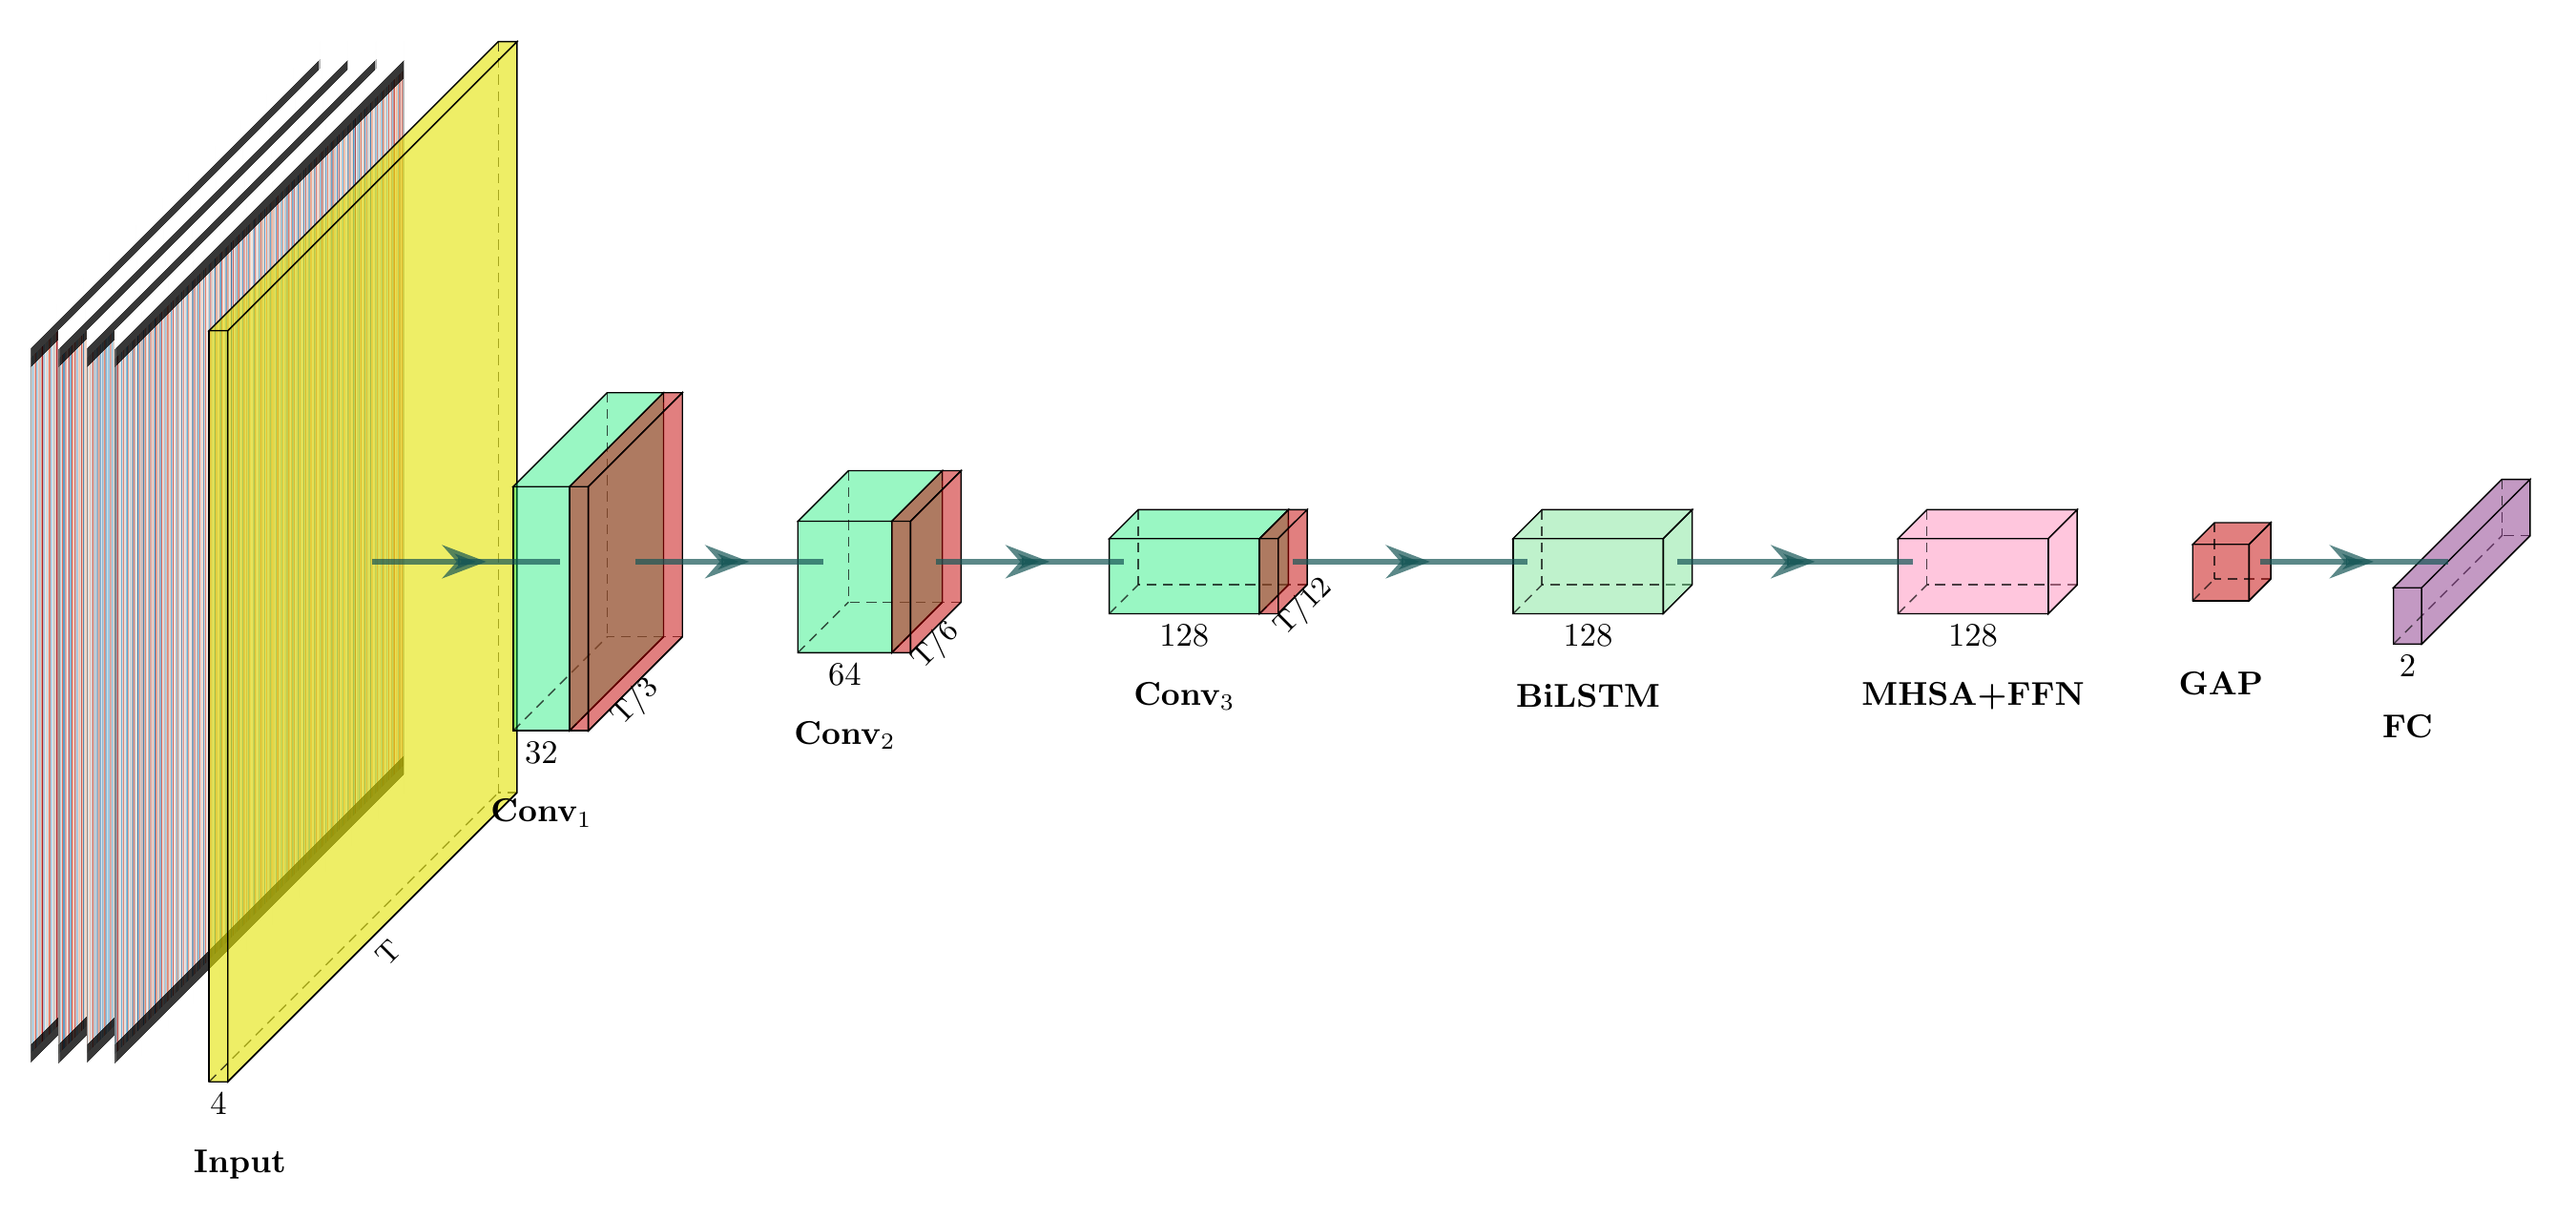

In [81]:
from IPython.display import Image, display
display(Image('pyramidal_bilstm_attn_preview-1.png'))

## Parameter Estimate

| Layer | Params |
|-------|--------|
| Conv1d(4→32, k=7, s=3) | 4×7×32 + 32 = 928 |
| BN(32) | 64 |
| Conv1d(32→64, k=5, s=2) | 32×5×64 + 64 = 10,304 |
| BN(64) | 128 |
| Conv1d(64→128, k=3, s=2) | 64×3×128 + 128 = 24,704 |
| BN(128) | 256 |
| BiLSTM(128→64, bidir) | 4×(128+64+1)×64 × 2 = 98,816 |
| Transformer(128, 4-head, mlp=2.0) | ~99K (MHSA + FFN) |
| Dense(128→2) | 258 |
| **Total** | **~135K** |

Sits between PyramidalCNN (33K) and CNNBiLSTMAttn (211K) — balanced.